In [1]:
# ============================================================
# NOTEBOOK 07
# FEDERATED LEARNING UNDER INTERMITTENT CONNECTIVITY
# ============================================================

"""
Objective

Simulate realistic Federated Learning where
clients may randomly disconnect due to
network failures or limited availability.

Pipeline

1. Load CIFAR-10
2. Load/Create Non-IID Partitions
3. Create CNN
4. Simulate Client Connectivity
5. Local Training
6. FedAvg
7. Evaluate Global Model
8. Save Results
"""

print("="*60)
print("NOTEBOOK 07")
print("FEDERATED LEARNING UNDER INTERMITTENT CONNECTIVITY")
print("="*60)

NOTEBOOK 07
FEDERATED LEARNING UNDER INTERMITTENT CONNECTIVITY


In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import copy
import pickle
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader
from torch.utils.data import Subset

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# ============================================================
# RANDOM SEED
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("="*60)
print("Device :",device)
print("="*60)

Device : cuda


In [4]:
# ============================================================
# LOAD CIFAR-10
# ============================================================

transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914,0.4822,0.4465),
        (0.2023,0.1994,0.2010)
    )

])

trainset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("="*60)
print("Training Images :",len(trainset))
print("Testing Images  :",len(testset))
print("="*60)

100%|██████████| 170M/170M [58:59<00:00, 48.2kB/s]


Training Images : 50000
Testing Images  : 10000


In [5]:
# ============================================================
# LOAD OR CREATE PARTITIONS
# ============================================================

PARTITION_DIR = "saved_partitions"

os.makedirs(PARTITION_DIR, exist_ok=True)

NONIID_FILE = os.path.join(
    PARTITION_DIR,
    "noniid_clients.pkl"
)

NUM_CLIENTS = 10
ALPHA = 0.3

if os.path.exists(NONIID_FILE):

    print("Loading saved partitions...")

    with open(NONIID_FILE,"rb") as f:

        noniid_clients = pickle.load(f)

else:

    print("Generating new partitions...")

    def dirichlet_partition(
        targets,
        num_clients,
        alpha
    ):

        targets=np.array(targets)

        client_indices=[
            [] for _ in range(num_clients)
        ]

        for cls in np.unique(targets):

            cls_idx=np.where(targets==cls)[0]

            np.random.shuffle(cls_idx)

            proportions=np.random.dirichlet(
                np.repeat(alpha,num_clients)
            )

            split=np.split(
                cls_idx,
                (
                    np.cumsum(proportions)
                    *len(cls_idx)
                ).astype(int)[:-1]
            )

            for i,idx in enumerate(split):

                client_indices[i].extend(idx)

        return client_indices

    noniid_clients = dirichlet_partition(
        trainset.targets,
        NUM_CLIENTS,
        ALPHA
    )

    with open(NONIID_FILE,"wb") as f:

        pickle.dump(
            noniid_clients,
            f
        )

print("="*60)
print("Clients :",len(noniid_clients))
print("="*60)

Generating new partitions...
Clients : 10


In [6]:
# ============================================================
# CNN MODEL
# ============================================================

class CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128*4*4,
                512
            ),

            nn.ReLU(),

            nn.Linear(
                512,
                10
            )

        )

    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x


print(CNN())

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [7]:
# ============================================================
# INITIALIZE GLOBAL MODEL
# ============================================================

global_model = CNN().to(device)

print("="*60)
print("Global Model Initialized")
print("="*60)

Global Model Initialized


In [8]:
# ============================================================
# CREATE CLIENT DATALOADERS
# ============================================================

client_loaders = []

for client in range(NUM_CLIENTS):

    subset = Subset(
        trainset,
        noniid_clients[client]
    )

    loader = DataLoader(
        subset,
        batch_size=64,
        shuffle=True
    )

    client_loaders.append(loader)

testloader = DataLoader(
    testset,
    batch_size=128,
    shuffle=False
)

print("="*60)
print("Created",len(client_loaders),"Client DataLoaders")
print("="*60)

Created 10 Client DataLoaders


In [9]:
# ============================================================
# MODEL EVALUATION
# ============================================================

def evaluate(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images,labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(1)

            total += labels.size(0)

            correct += (predictions==labels).sum().item()

    return 100 * correct / total

print("Evaluation Function Ready")

Evaluation Function Ready


In [10]:
# ============================================================
# LOCAL TRAINING
# ============================================================

def local_train(model,
                loader,
                epochs=1,
                lr=0.001):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    model.train()

    for _ in range(epochs):

        for images,labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs,labels)

            loss.backward()

            optimizer.step()

    return model.state_dict()

print("Local Training Ready")

Local Training Ready


In [11]:
# ============================================================
# FEDAVG
# ============================================================

def federated_average(client_weights):

    average = copy.deepcopy(client_weights[0])

    for key in average.keys():

        for i in range(1,len(client_weights)):

            average[key] += client_weights[i][key]

        average[key] /= len(client_weights)

    return average

print("FedAvg Ready")

FedAvg Ready


In [12]:
# ============================================================
# INTERMITTENT CONNECTIVITY SIMULATOR
# ============================================================

client_profiles = {

    0:0.95,
    1:0.90,
    2:0.85,

    3:0.70,
    4:0.70,
    5:0.70,

    6:0.50,
    7:0.50,
    8:0.40,
    9:0.40

}

def available_clients():

    active = []

    for client in range(NUM_CLIENTS):

        if random.random() < client_profiles[client]:

            active.append(client)

    if len(active)==0:

        active.append(random.randint(0,NUM_CLIENTS-1))

    return active

print("="*60)
print("Connectivity Simulator Ready")
print("="*60)

Connectivity Simulator Ready


In [13]:
# ============================================================
# FEDERATED LEARNING
# WITH INTERMITTENT CONNECTIVITY
# ============================================================

ROUNDS = 10
LOCAL_EPOCHS = 1

accuracy_history = []
participation_history = []

for rnd in range(ROUNDS):

    print(f"\nCommunication Round {rnd+1}/{ROUNDS}")

    active_clients = available_clients()

    participation_history.append(
        len(active_clients)
    )

    print("Online Clients :",active_clients)

    client_weights = []

    for client in active_clients:

        local_model = copy.deepcopy(
            global_model
        ).to(device)

        weights = local_train(
            local_model,
            client_loaders[client],
            LOCAL_EPOCHS
        )

        client_weights.append(weights)

    averaged = federated_average(
        client_weights
    )

    global_model.load_state_dict(
        averaged
    )

    acc = evaluate(global_model)

    accuracy_history.append(acc)

    print(
        f"Global Accuracy : {acc:.2f}%"
    )


Communication Round 1/10
Online Clients : [0, 1, 2, 3, 5, 7, 9]
Global Accuracy : 15.84%

Communication Round 2/10
Online Clients : [0, 1, 2, 3, 4, 5, 6, 9]
Global Accuracy : 25.47%

Communication Round 3/10
Online Clients : [0, 1, 2, 3, 5, 6, 7]
Global Accuracy : 29.86%

Communication Round 4/10
Online Clients : [0, 1, 2, 4, 5]
Global Accuracy : 34.03%

Communication Round 5/10
Online Clients : [0, 1, 2, 3, 4, 5, 6, 7, 9]
Global Accuracy : 40.28%

Communication Round 6/10
Online Clients : [0, 1, 2, 4, 5, 6, 8, 9]
Global Accuracy : 46.37%

Communication Round 7/10
Online Clients : [1, 2, 3, 6, 7, 8, 9]
Global Accuracy : 44.29%

Communication Round 8/10
Online Clients : [0, 3, 4, 5, 7, 8, 9]
Global Accuracy : 41.52%

Communication Round 9/10
Online Clients : [0, 1, 2, 4, 5, 8, 9]
Global Accuracy : 52.89%

Communication Round 10/10
Online Clients : [0, 1, 2, 3, 4, 5]
Global Accuracy : 50.97%


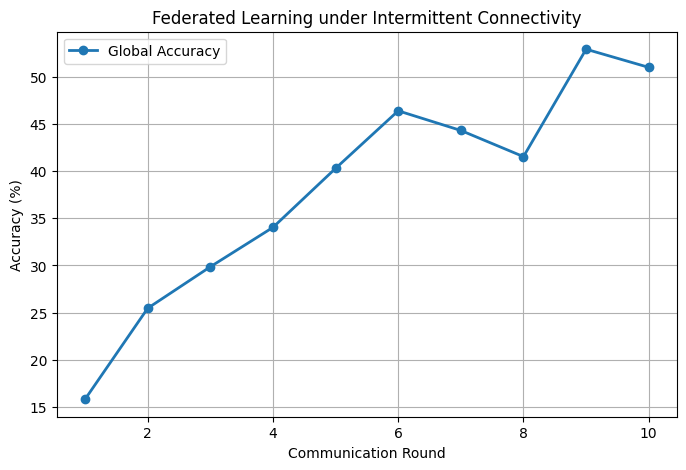

In [14]:
# ============================================================
# GLOBAL ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, ROUNDS + 1),
    accuracy_history,
    marker="o",
    linewidth=2,
    label="Global Accuracy"
)

plt.xlabel("Communication Round")
plt.ylabel("Accuracy (%)")
plt.title("Federated Learning under Intermittent Connectivity")

plt.grid(True)
plt.legend()

plt.show()

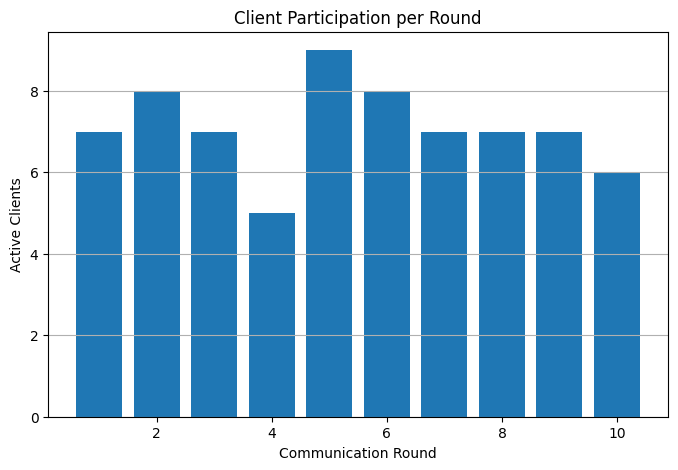

Average Active Clients : 7.1
Maximum Active Clients : 9
Minimum Active Clients : 5


In [15]:
# ============================================================
# CLIENT PARTICIPATION
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    range(1, ROUNDS + 1),
    participation_history
)

plt.xlabel("Communication Round")
plt.ylabel("Active Clients")
plt.title("Client Participation per Round")

plt.grid(axis="y")

plt.show()

print("="*60)
print("Average Active Clients :", np.mean(participation_history))
print("Maximum Active Clients :", np.max(participation_history))
print("Minimum Active Clients :", np.min(participation_history))
print("="*60)

In [16]:
# ============================================================
# SAVE RESULTS
# ============================================================

RESULT_DIR = "results"

os.makedirs(RESULT_DIR, exist_ok=True)

results = pd.DataFrame({

    "Round": range(1, ROUNDS + 1),

    "Accuracy": accuracy_history,

    "Active Clients": participation_history

})

results.to_csv(

    os.path.join(
        RESULT_DIR,
        "intermittent_connectivity_results.csv"
    ),

    index=False

)

print(results)

   Round  Accuracy  Active Clients
0      1     15.84               7
1      2     25.47               8
2      3     29.86               7
3      4     34.03               5
4      5     40.28               9
5      6     46.37               8
6      7     44.29               7
7      8     41.52               7
8      9     52.89               7
9     10     50.97               6


In [17]:
# ============================================================
# SAVE GLOBAL MODEL
# ============================================================

MODEL_DIR = "saved_models"

os.makedirs(MODEL_DIR, exist_ok=True)

torch.save(

    global_model.state_dict(),

    os.path.join(
        MODEL_DIR,
        "intermittent_connectivity_global_model.pth"
    )

)

print("="*60)
print("Global Model Saved")
print("="*60)

Global Model Saved


In [18]:
# ============================================================
# SUMMARY
# ============================================================

print("="*60)
print("FEDERATED LEARNING WITH")
print("INTERMITTENT CONNECTIVITY COMPLETED")
print("="*60)

print(f"Communication Rounds     : {ROUNDS}")
print(f"Total Clients            : {NUM_CLIENTS}")
print(f"Average Active Clients   : {np.mean(participation_history):.2f}")
print(f"Final Accuracy           : {accuracy_history[-1]:.2f}%")

communication_efficiency = (
    np.mean(participation_history) / NUM_CLIENTS
) * 100

print(f"Communication Efficiency : {communication_efficiency:.2f}%")

print("="*60)

FEDERATED LEARNING WITH
INTERMITTENT CONNECTIVITY COMPLETED
Communication Rounds     : 10
Total Clients            : 10
Average Active Clients   : 7.10
Final Accuracy           : 50.97%
Communication Efficiency : 71.00%
